In [35]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tqdm as tqdm

In [36]:
img1 = cv2.imread('assignment_2_materials/pano_image2.jpg')
img2 = cv2.imread('assignment_2_materials/pano_image1.jpg')
gray_img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

### SIFT detector


In [37]:
sift_detector=cv2.SIFT_create()

# Detect keypoints and descriptors
keypoints1, descriptors1 = sift_detector.detectAndCompute(gray_img1, None)
keypoints2, descriptors2 = sift_detector.detectAndCompute(gray_img2, None)

# Match descriptors using KNN
bf = cv2.BFMatcher()
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Apply ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)
good_matches = sorted(good_matches, key=lambda x: x.distance)

### Viewing the Good matches


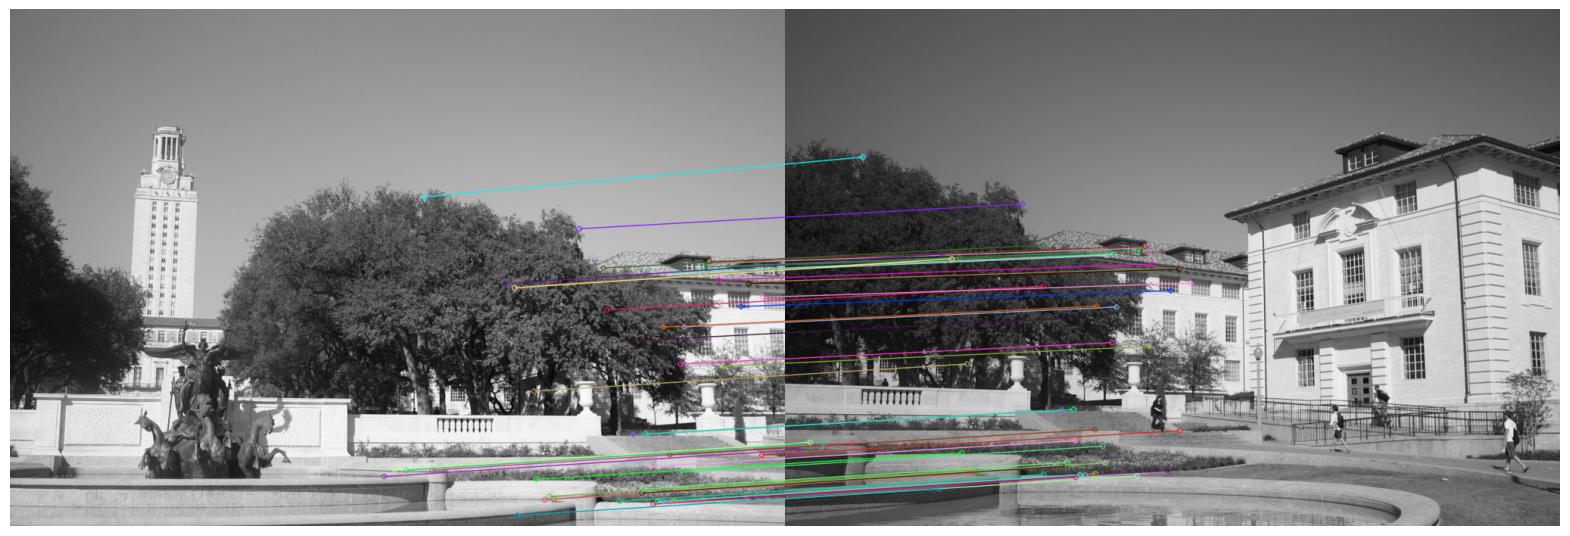

In [38]:
good_matches = good_matches[:50]
img_matches = cv2.drawMatches(gray_img1, keypoints1, gray_img2, keypoints2, good_matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(20, 10))
plt.imshow(img_matches)
plt.axis('off')
plt.show()

In [39]:
def compute_homography(src_pts, dst_pts):

    if len(src_pts) < 4:
        raise ValueError("Need at least 4 points to compute homography")
    # Aih = 0
    # [-x, -y, -1,  0,  0,  0, x * x', y * x', x']
    # [ 0,  0,  0, -x, -y, -1, x * y', y * y', y']


    N = len(src_pts)
    A = []
    for i in range(N):
        (x, y) = src_pts[i]
        (xp, yp) = dst_pts[i]
        A.append([-x, -y, -1,  0,  0,  0, x * xp, y * xp, xp])
        A.append([ 0,  0,  0, -x, -y, -1, x * yp, y * yp, yp])

    A = np.array(A)

    # Solve using SVD: A*h = 0 -> smallest singular value
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1]  # Solution is last row of V^T
    H = h.reshape(3, 3)

    # Normalize so that H[2,2] == 1
    return H / H[2, 2]
def apply_homography(H, pts):
    pts_homog = np.hstack([pts, np.ones((pts.shape[0], 1))])
    projected = (H @ pts_homog.T).T
    projected /= projected[:, 2][:, np.newaxis]
    return projected[:, :2]


In [40]:
def compute_homography_rnsac(src_pts, dst_pts, threshold=4.0, max_iter=2000) : 
    max_inliers = 0
    best_H = None
    best_inliers_mask = None

    src_pts = np.array(src_pts)
    dst_pts = np.array(dst_pts)

    for _ in range(max_iter):
        idx = np.random.choice(len(src_pts), 4)
        src_sample = src_pts[idx]
        dst_sample = dst_pts[idx]

        try:
            H = compute_homography(src_sample, dst_sample)
        except ValueError:
            continue

        projected = apply_homography(H, src_pts)
        errors = np.linalg.norm(projected - dst_pts, axis=1)
        inlier_mask = errors < threshold
        num_inliers = np.sum(inlier_mask)

        if num_inliers > max_inliers:
            max_inliers = num_inliers
            best_H = H
            best_inliers_mask = inlier_mask
        
    if best_inliers_mask is not None and np.sum(best_inliers_mask) >= 4:
        final_src_pts = src_pts[best_inliers_mask]
        final_dst_pts = dst_pts[best_inliers_mask]
        best_H = compute_homography(final_src_pts, final_dst_pts)

    return best_H, best_inliers_mask        

Homography Matrix:
[[ 1.31300123e+00 -7.75705227e-02 -5.80984901e+02]
 [ 1.74950253e-01  1.22837502e+00 -1.72293000e+02]
 [ 2.91512216e-04  2.04681590e-05  1.00000000e+00]]


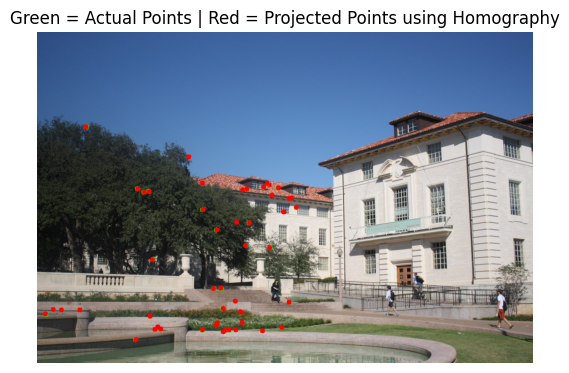

In [42]:

src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in good_matches])
H, _=compute_homography_rnsac(src_pts, dst_pts)
print("Homography Matrix:")
print(H)

projected_pts = apply_homography(H, src_pts)

draw = img2.copy()
# Draw the projected points on the original image
for actual, projected in zip(dst_pts, projected_pts):
    actual = tuple(np.round(actual).astype(int))
    projected = tuple(np.round(projected).astype(int))

    # Draw actual point (green)
    cv2.circle(draw, actual, 5, (0, 255, 0), -1)
    # Draw projected point (red)
    cv2.circle(draw, projected, 5, (0, 0, 255), -1)

plt.imshow(cv2.cvtColor(draw, cv2.COLOR_BGR2RGB))
plt.title("Green = Actual Points | Red = Projected Points using Homography")
plt.axis('off')
plt.show()